In [4]:
!pip install seaborn
!pip install -U scikit-learn

  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 25.3 MB/s  0:00:00 eta 0:00:01
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


Loading data and model...


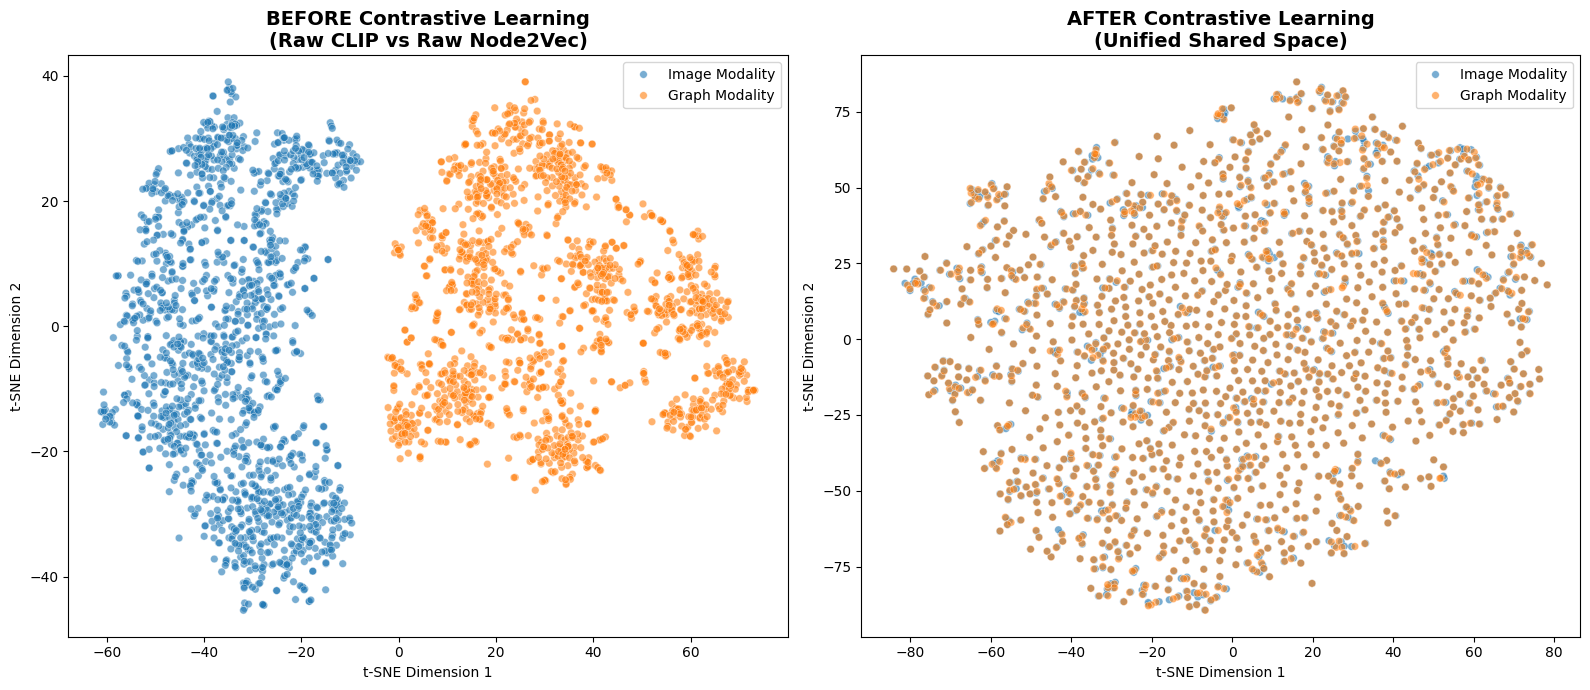

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

class ProjectionHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        x = self.mlp(x)
        return F.normalize(x, p=2, dim=1)

class MultiModalAlignmentModel(nn.Module):
    def __init__(self, img_in_dim=512, graph_in_dim=512, shared_dim=256):
        super().__init__()
        self.image_proj = ProjectionHead(input_dim=img_in_dim, hidden_dim=512, output_dim=shared_dim)
        self.graph_proj = ProjectionHead(input_dim=graph_in_dim, hidden_dim=512, output_dim=shared_dim)

    def forward(self, img_embeds, graph_embeds):
        return self.image_proj(img_embeds), self.graph_proj(graph_embeds)

print("Loading data and model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load raw embeddings
raw_images = np.load('image_embeddings.npy')
raw_graphs = np.load('graph_embeddings.npy')

# Load Trained Model
model = MultiModalAlignmentModel(img_in_dim=512, graph_in_dim=512, shared_dim=256).to(device)
model.load_state_dict(torch.load('multimodal_projection_heads.pth', map_location=device))
model.eval()

# Sample 1500 random paintings so the plot is readable
num_samples = 1500
indices = np.random.choice(raw_images.shape[0], num_samples, replace=False)

sample_raw_images = torch.tensor(raw_images[indices], dtype=torch.float32).to(device)
sample_raw_graphs = torch.tensor(raw_graphs[indices], dtype=torch.float32).to(device)

# Get the "After" embeddings from the shared space
with torch.no_grad():
    proj_images, proj_graphs = model(sample_raw_images, sample_raw_graphs)
    
    # Move back to CPU for t-SNE
    proj_images = proj_images.cpu().numpy()
    proj_graphs = proj_graphs.cpu().numpy()
    
sample_raw_images = sample_raw_images.cpu().numpy()
sample_raw_graphs = sample_raw_graphs.cpu().numpy()

# Combine the Image and Graph arrays for the "Before" plot
combined_raw = np.vstack((sample_raw_images, sample_raw_graphs))
# Combine the Image and Graph arrays for the "After" plot
combined_proj = np.vstack((proj_images, proj_graphs))

# Labels for coloring (0 for Image, 1 for Graph)
labels = ['Image Modality'] * num_samples + ['Graph Modality'] * num_samples

# Run t-SNE
tsne_raw = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(combined_raw)
tsne_proj = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(combined_proj)

# PLOT THE RESULTS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Before Contrastive Learning
sns.scatterplot(
    x=tsne_raw[:, 0], y=tsne_raw[:, 1],
    hue=labels, palette=['#1f77b4', '#ff7f0e'],
    alpha=0.6, s=30, ax=axes[0]
)
axes[0].set_title("BEFORE Contrastive Learning\n(Raw CLIP vs Raw Node2Vec)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")

# Plot 2: After Contrastive Learning
sns.scatterplot(
    x=tsne_proj[:, 0], y=tsne_proj[:, 1],
    hue=labels, palette=['#1f77b4', '#ff7f0e'],
    alpha=0.6, s=30, ax=axes[1]
)
axes[1].set_title("AFTER Contrastive Learning\n(Unified Shared Space)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")

plt.tight_layout()
plt.show()

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# ==========================================
# 1. REDEFINE THE UPGRADED ARCHITECTURE
# ==========================================
class ProjectionHeadPro(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.2):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), 
            nn.ReLU(),
            nn.Dropout(dropout_rate),   
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        x = self.mlp(x)
        return F.normalize(x, p=2, dim=1)

class MultiModalAlignmentModelPro(nn.Module):
    def __init__(self, img_in_dim=512, graph_in_dim=512, shared_dim=256):
        super().__init__()
        self.image_proj = ProjectionHeadPro(input_dim=img_in_dim, hidden_dim=512, output_dim=shared_dim)
        self.graph_proj = ProjectionHeadPro(input_dim=graph_in_dim, hidden_dim=512, output_dim=shared_dim)
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

    def forward(self, img_embeds, graph_embeds):
        return self.image_proj(img_embeds), self.graph_proj(graph_embeds)

# ==========================================
# 2. LOAD THE MODEL AND WEIGHTS
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the Pro model
model_pro = MultiModalAlignmentModelPro(img_in_dim=512, graph_in_dim=512, shared_dim=256).to(device)

# Load the V2 weights (Make sure the file name matches what you saved!)
model_pro.load_state_dict(torch.load('multimodal_projection_heads_v2.pth', map_location=device))

# CRITICAL: Put model in evaluation mode
model_pro.eval()
print("✅ Pro Model successfully loaded!")

# ==========================================
# 3. LOAD RAW DATA & PROJECT INTO SHARED SPACE
# ==========================================
# Load your raw datasets 
raw_images = torch.tensor(np.load('image_embeddings.npy'), dtype=torch.float32).to(device)
raw_graphs = torch.tensor(np.load('graph_embeddings.npy'), dtype=torch.float32).to(device)

print("Projecting embeddings into the shared space...")
with torch.no_grad():
    shared_images = model_pro.image_proj(raw_images)
    shared_graphs = model_pro.graph_proj(raw_graphs)
    
    # Move to CPU for numpy operations
    shared_images = shared_images.cpu().numpy()
    shared_graphs = shared_graphs.cpu().numpy()

# ==========================================
# 4. CROSS-MODAL EVALUATION (Image -> Graph)
# ==========================================
print("Calculating similarities...")
# Calculate how well EVERY image matches with EVERY graph
cross_modal_scores = shared_images.dot(shared_graphs.T)

def calculate_recall_at_k(similarity_matrix, k_values=[1, 5, 10, 50]):
    N = similarity_matrix.shape[0]
    
    # Get indices of the highest scoring graphs for each image
    top_k_indices = np.argsort(similarity_matrix, axis=1)[:, ::-1]
    
    recalls = {}
    for k in k_values:
        correct_retrievals = 0
        for i in range(N):
            # Check if the correct graph (index i) is in the top K predictions
            if i in top_k_indices[i, :k]:
                correct_retrievals += 1
                
        recalls[f'Recall@{k}'] = (correct_retrievals / N) * 100
    
    return recalls

print("\n=== CROSS-MODAL RETRIEVAL ACCURACY (IMAGE -> GRAPH) ===")
recalls = calculate_recall_at_k(cross_modal_scores, k_values=[1, 5, 10, 50, 100])

for metric, score in recalls.items():
    print(f"{metric}: {score:.2f}%")

Using device: cuda
✅ Pro Model successfully loaded!
Projecting embeddings into the shared space...
Calculating similarities...

=== CROSS-MODAL RETRIEVAL ACCURACY (IMAGE -> GRAPH) ===
Recall@1: 83.91%
Recall@5: 99.38%
Recall@10: 99.94%
Recall@50: 100.00%
Recall@100: 100.00%
